# VM2 Decision Tree Baseline — Stratified 80/20 Split

This notebook contains the VM2 Decision Tree baseline using the existing project preprocessing pipeline and a stratified 80/20 train-test split.

## Imports, Configuration, and Helper Functions


In [1]:
from __future__ import annotations

import os
from pathlib import Path

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

BASE_DIR = Path.cwd()
MPL_CONFIG_DIR = BASE_DIR / ".matplotlib"
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CONFIG_DIR))

try:
    import matplotlib

    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    matplotlib = None
    plt = None


INPUT_FILE = Path("outputs/clean_network_flows.csv")
METADATA_FILE = Path("outputs/cti_mapping_metadata.csv")
FEATURE_RECOMMENDATIONS_FILE = Path("outputs/feature_analysis/feature_relevance_recommendations.csv")
METRICS_OUTPUT_FILE = Path("outputs/decision_tree_80_20_metrics.csv")
PREDICTIONS_OUTPUT_FILE = Path("outputs/decision_tree_80_20_predictions.csv")
FEATURE_IMPORTANCE_OUTPUT_FILE = Path("outputs/decision_tree_feature_importance.csv")

DEFAULT_NUMERICAL_FEATURES = [
    "id.orig_p",
    "id.resp_p",
    "duration",
    "orig_bytes",
    "resp_bytes",
    "missed_bytes",
    "orig_pkts",
    "orig_ip_bytes",
    "resp_pkts",
    "resp_ip_bytes",
]
DEFAULT_CATEGORICAL_FEATURES = ["proto", "service", "conn_state", "history"]
TARGET_COLUMN = "label"
ROW_ID_COLUMN = "flow_row_id"
CAPTURE_DATE_COLUMN = "capture_date"

TRAIN_RATIO = 0.80

def load_approved_features() -> tuple[list[str], list[str]]:
    if not FEATURE_RECOMMENDATIONS_FILE.exists():
        return DEFAULT_NUMERICAL_FEATURES, DEFAULT_CATEGORICAL_FEATURES

    recommendations = pd.read_csv(FEATURE_RECOMMENDATIONS_FILE)
    approved = recommendations.loc[recommendations["recommendation"] != "DROP", "feature"].tolist()
    numerical = [feature for feature in DEFAULT_NUMERICAL_FEATURES if feature in approved]
    categorical = [feature for feature in DEFAULT_CATEGORICAL_FEATURES if feature in approved]
    return numerical, categorical


def build_pipeline(numerical_features: list[str], categorical_features: list[str]) -> Pipeline:
    numerical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numerical_pipeline, numerical_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", DecisionTreeClassifier(random_state=42)),
        ]
    )


def compute_metrics(y_true: pd.Series, y_pred: pd.Series, y_prob: pd.Series) -> dict[str, object]:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    false_positive_rate = fp / (fp + tn) if (fp + tn) else 0.0
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "false_positive_rate": false_positive_rate,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "classification_report": classification_report(y_true, y_pred, digits=4),
    }


def verify_unique_row_ids(dataframe: pd.DataFrame, source_name: str) -> None:
    if dataframe[ROW_ID_COLUMN].duplicated().any():
        duplicate_count = int(dataframe[ROW_ID_COLUMN].duplicated().sum())
        raise ValueError(f"{source_name} contains {duplicate_count} duplicated {ROW_ID_COLUMN} values.")


def load_modeling_dataframe_with_capture_dates() -> pd.DataFrame:
    modeling_dataframe = pd.read_csv(INPUT_FILE)
    metadata_dataframe = pd.read_csv(METADATA_FILE, usecols=[ROW_ID_COLUMN, CAPTURE_DATE_COLUMN])

    verify_unique_row_ids(modeling_dataframe, str(INPUT_FILE))
    verify_unique_row_ids(metadata_dataframe, str(METADATA_FILE))

    merged_dataframe = modeling_dataframe.merge(
        metadata_dataframe,
        on=ROW_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )

    if len(merged_dataframe) != len(modeling_dataframe):
        raise ValueError("Joining capture_date changed the number of modelling records.")
    if merged_dataframe[CAPTURE_DATE_COLUMN].isna().any():
        missing_count = int(merged_dataframe[CAPTURE_DATE_COLUMN].isna().sum())
        raise ValueError(f"Join left {missing_count} modelling records without capture_date.")

    return merged_dataframe


def print_capture_date_distribution(dataframe: pd.DataFrame) -> None:
    distribution = (
        dataframe.assign(
            class_name=dataframe[TARGET_COLUMN].map({0: "Benign", 1: "Malicious"}).fillna("Unknown")
        )
        .groupby([CAPTURE_DATE_COLUMN, "class_name"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    for class_name in ["Benign", "Malicious"]:
        if class_name not in distribution.columns:
            distribution[class_name] = 0
    distribution = distribution[["Benign", "Malicious"]]
    distribution["Total"] = distribution["Benign"] + distribution["Malicious"]

    print("\nBenign/Malicious distribution for every capture_date:")
    print(distribution.to_string())

def print_label_distribution(split_name: str, labels: pd.Series) -> None:
    distribution = (
        labels.map({0: "Benign", 1: "Malicious"})
        .value_counts()
        .reindex(["Benign", "Malicious"], fill_value=0)
    )
    print(f"\n{split_name} class distribution:")
    print(distribution.to_string())


def save_metrics(
    train_accuracy: float,
    train_f1: float,
    test_metrics: dict[str, object],
    train_samples: int,
    test_samples: int,
) -> None:
    metrics_rows = [
        {"metric": "train_accuracy", "value": train_accuracy},
        {"metric": "train_f1_score", "value": train_f1},
        {"metric": "test_accuracy", "value": test_metrics["accuracy"]},
        {"metric": "test_precision", "value": test_metrics["precision"]},
        {"metric": "test_recall", "value": test_metrics["recall"]},
        {"metric": "test_f1_score", "value": test_metrics["f1_score"]},
        {"metric": "test_false_positive_rate", "value": test_metrics["false_positive_rate"]},
        {"metric": "test_roc_auc", "value": test_metrics["roc_auc"]},
        {"metric": "true_negatives", "value": test_metrics["true_negatives"]},
        {"metric": "false_positives", "value": test_metrics["false_positives"]},
        {"metric": "false_negatives", "value": test_metrics["false_negatives"]},
        {"metric": "true_positives", "value": test_metrics["true_positives"]},
        {"metric": "train_samples", "value": train_samples},
        {"metric": "test_samples", "value": test_samples},
    ]
    pd.DataFrame(metrics_rows).to_csv(METRICS_OUTPUT_FILE, index=False)


def save_predictions(
    row_ids: pd.Series,
    y_true: pd.Series,
    y_pred: pd.Series,
    y_prob: pd.Series,
) -> None:
    predictions = pd.DataFrame(
        {
            "flow_row_id": row_ids.to_numpy(),
            "true_label": y_true.to_numpy(),
            "predicted_label": y_pred,
            "predicted_probability": y_prob,
        }
    ).sort_values("flow_row_id")
    predictions.to_csv(PREDICTIONS_OUTPUT_FILE, index=False)


def maybe_create_visualisations(
    pipeline: Pipeline,
    y_test: pd.Series,
    y_test_pred: pd.Series,
    y_test_prob,
    test_dataframe: pd.DataFrame,
) -> list[Path]:
    if plt is None:
        return []
    create_confusion_matrix_figure(y_test, y_test_pred)
    create_roc_curve_figure(y_test, y_test_prob)
    feature_importance_file = create_feature_importance_outputs(pipeline)

    if CAPTURE_DATE_COLUMN in test_dataframe.columns:
        create_daily_performance_figure(test_dataframe, y_test, y_test_pred)

    return [feature_importance_file]


def create_confusion_matrix_figure(y_true: pd.Series, y_pred: pd.Series) -> None:
    matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(matrix, cmap="Blues")
    fig.colorbar(image, ax=ax)

    ax.set_title("Decision Tree - Confusion Matrix\nStratified 80/20 Test Set")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1], labels=["Benign", "Malicious"])
    ax.set_yticks([0, 1], labels=["Benign", "Malicious"])

    labels = [["TN", "FP"], ["FN", "TP"]]
    threshold = matrix.max() / 2 if matrix.size else 0
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            value = int(matrix[row_index, column_index])
            text_color = "white" if value > threshold else "black"
            ax.text(
                column_index,
                row_index,
                f"{labels[row_index][column_index]}\n{value}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=11,
            )

    fig.tight_layout()
    fig.savefig("outputs/figures/decision_tree_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def create_roc_curve_figure(y_true: pd.Series, y_prob) -> None:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color="#1f4e79", linewidth=2, label=f"Decision Tree (AUC = {roc_auc:.4f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.2, label="Random classifier")
    ax.set_title("Decision Tree - ROC Curve\nStratified 80/20 Test Set")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    fig.tight_layout()
    fig.savefig("outputs/figures/decision_tree_roc_curve.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def create_feature_importance_outputs(pipeline: Pipeline) -> Path:
    preprocessor = pipeline.named_steps["preprocessor"]
    classifier = pipeline.named_steps["classifier"]
    transformed_feature_names = list(preprocessor.get_feature_names_out())
    raw_importances = classifier.feature_importances_

    aggregated_importances: dict[str, float] = {feature: 0.0 for feature in DEFAULT_NUMERICAL_FEATURES + DEFAULT_CATEGORICAL_FEATURES}
    for transformed_name, importance in zip(transformed_feature_names, raw_importances):
        original_feature = map_transformed_feature_to_original(transformed_name)
        aggregated_importances[original_feature] = aggregated_importances.get(original_feature, 0.0) + float(importance)

    feature_importance = (
        pd.DataFrame(
            {
                "feature": list(aggregated_importances.keys()),
                "importance": list(aggregated_importances.values()),
            }
        )
        .sort_values("importance", ascending=False, kind="stable")
        .reset_index(drop=True)
    )
    feature_importance.to_csv(FEATURE_IMPORTANCE_OUTPUT_FILE, index=False)

    fig, ax = plt.subplots(figsize=(10, 7))
    plot_dataframe = feature_importance.sort_values("importance", ascending=True, kind="stable")
    ax.barh(plot_dataframe["feature"], plot_dataframe["importance"], color="#1f4e79")
    ax.set_title("Decision Tree - Feature Importance")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_axisbelow(True)

    fig.tight_layout()
    fig.savefig("outputs/figures/decision_tree_feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return FEATURE_IMPORTANCE_OUTPUT_FILE


def map_transformed_feature_to_original(transformed_name: str) -> str:
    if transformed_name.startswith("num__"):
        return transformed_name.replace("num__", "", 1)

    if transformed_name.startswith("cat__"):
        cleaned_name = transformed_name.replace("cat__", "", 1)
        for categorical_feature in DEFAULT_CATEGORICAL_FEATURES:
            if cleaned_name == categorical_feature or cleaned_name.startswith(f"{categorical_feature}_"):
                return categorical_feature
        return cleaned_name

    return transformed_name


def create_daily_performance_figure(
    test_dataframe: pd.DataFrame,
    y_true: pd.Series,
    y_pred: pd.Series,
) -> None:
    daily_dataframe = pd.DataFrame(
        {
            CAPTURE_DATE_COLUMN: test_dataframe[CAPTURE_DATE_COLUMN].astype(str).to_numpy(),
            "true_label": y_true.to_numpy(),
            "predicted_label": y_pred,
        }
    )

    daily_rows: list[dict[str, float | str]] = []
    for capture_date in sorted(daily_dataframe[CAPTURE_DATE_COLUMN].unique()):
        daily_subset = daily_dataframe.loc[daily_dataframe[CAPTURE_DATE_COLUMN] == capture_date].copy()
        if daily_subset.empty:
            daily_rows.append(
                {
                    "capture_date": capture_date,
                    "accuracy": float("nan"),
                    "precision": float("nan"),
                    "recall": float("nan"),
                    "f1_score": float("nan"),
                }
            )
            continue

        y_true_day = daily_subset["true_label"].astype(int)
        y_pred_day = daily_subset["predicted_label"].astype(int)
        has_positive_class = bool((y_true_day == 1).any())
        daily_rows.append(
            {
                "capture_date": capture_date,
                "accuracy": accuracy_score(y_true_day, y_pred_day),
                "precision": precision_score(y_true_day, y_pred_day, zero_division=0) if has_positive_class else float("nan"),
                "recall": recall_score(y_true_day, y_pred_day, zero_division=0) if has_positive_class else float("nan"),
                "f1_score": f1_score(y_true_day, y_pred_day, zero_division=0) if has_positive_class else float("nan"),
            }
        )

    performance_dataframe = pd.DataFrame(daily_rows)

    fig, ax = plt.subplots(figsize=(10, 6))
    x_positions = range(len(performance_dataframe))
    ax.plot(x_positions, performance_dataframe["accuracy"], marker="o", linewidth=2, label="Accuracy")
    ax.plot(x_positions, performance_dataframe["precision"], marker="o", linewidth=2, label="Precision")
    ax.plot(x_positions, performance_dataframe["recall"], marker="o", linewidth=2, label="Recall")
    ax.plot(x_positions, performance_dataframe["f1_score"], marker="o", linewidth=2, label="F1")
    ax.set_title("Decision Tree - Daily Performance (Stratified 80/20 Test Set)")
    ax.set_xlabel("Capture date")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(list(x_positions), labels=performance_dataframe["capture_date"])
    ax.legend()
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

    fig.tight_layout()
    fig.savefig("outputs/figures/decision_tree_daily_performance.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)




## Train, Evaluate, and Generate Visualisations


Decision Tree stratified 80/20 binary baseline
Input dataset: outputs\clean_network_flows.csv
Metadata dataset: outputs\cti_mapping_metadata.csv
Final feature list used: ['id.orig_p', 'id.resp_p', 'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'proto', 'service', 'conn_state', 'history']

Benign/Malicious distribution for every capture_date:
class_name    Benign  Malicious  Total
capture_date                          
2023-02-20      4503          0   4503
2023-02-21      7759       2755  10514
2023-02-22     12023       5637  17660
2023-02-23      8760       1310  10070
2023-02-24     21542          2  21544
2023-02-25     10341          0  10341
2023-02-26      5822          0   5822

Split method: Stratified 80/20
Training proportion: 80%
Testing proportion: 20%

Train sample count: 64363
Test sample count: 16091

Train class distribution:
label
Benign       56600
Malicious     7763

Test class distribution:
label


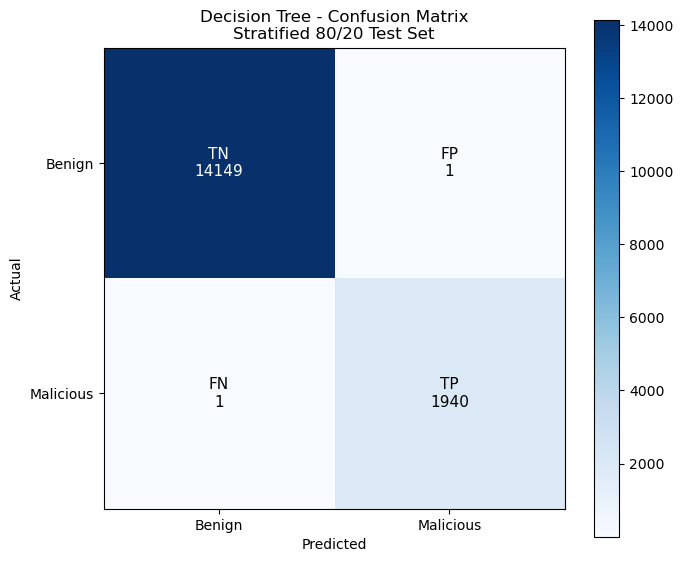

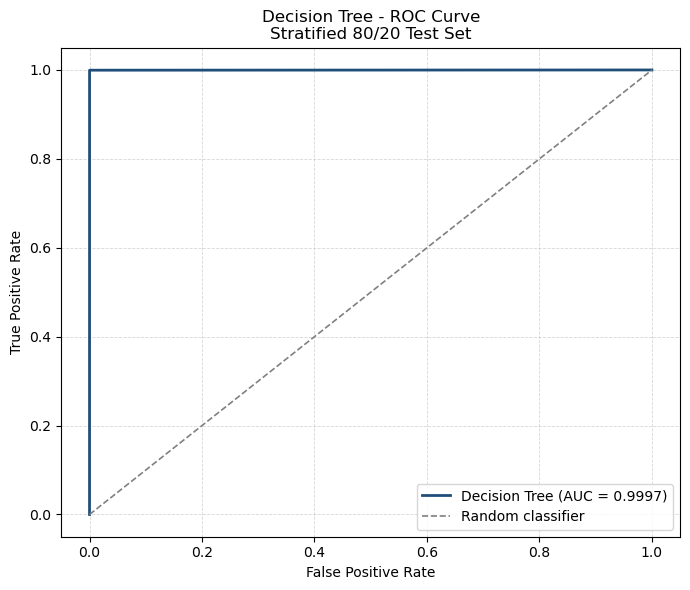

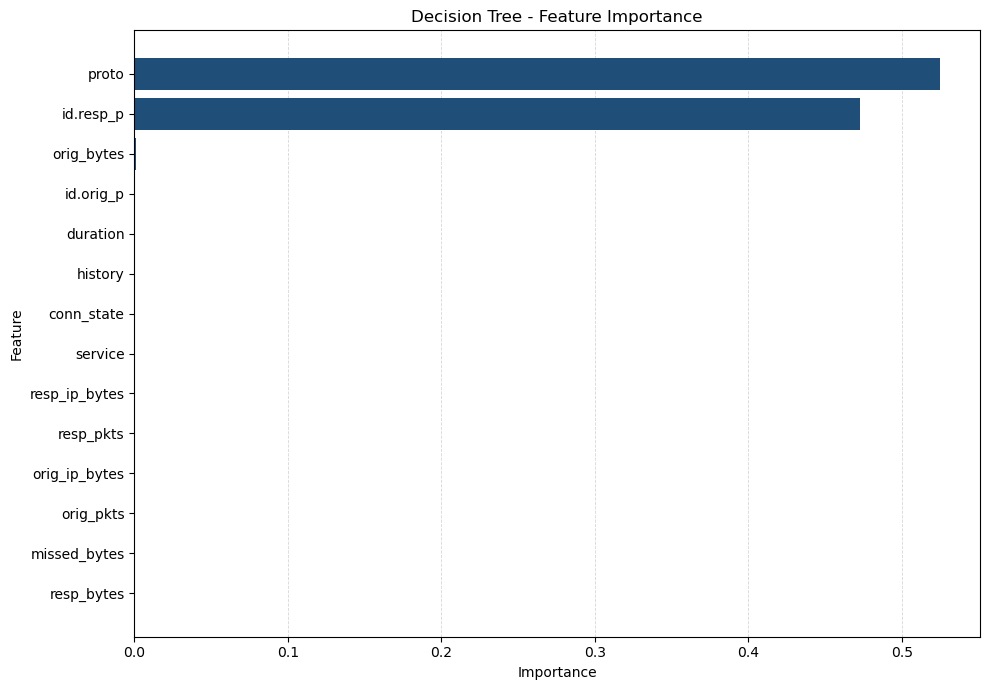

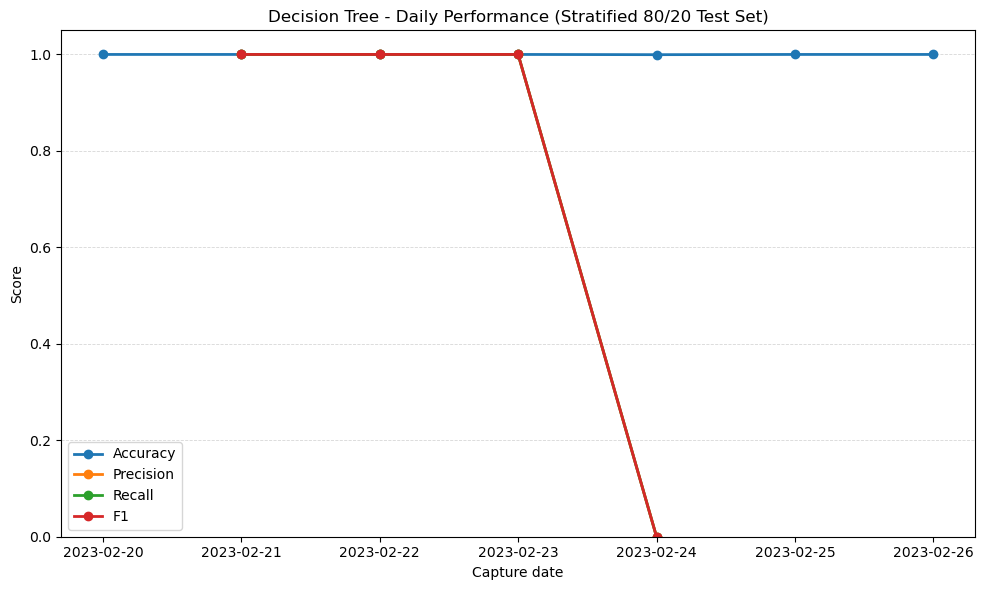


Visualisations displayed interactively.


In [2]:
def main() -> None:
    dataframe = load_modeling_dataframe_with_capture_dates()
    numerical_features, categorical_features = load_approved_features()
    final_features = numerical_features + categorical_features

    print("Decision Tree stratified 80/20 binary baseline")
    print(f"Input dataset: {INPUT_FILE}")
    print(f"Metadata dataset: {METADATA_FILE}")
    print(f"Final feature list used: {final_features}")
    print_capture_date_distribution(dataframe)

    # Stratified 80/20 train-test split.
    train_dataframe, test_dataframe = train_test_split(
        dataframe,
        test_size=1 - TRAIN_RATIO,
        random_state=42,
        stratify=dataframe[TARGET_COLUMN],
    )

    print("\nSplit method: Stratified 80/20")
    print(f"Training proportion: {TRAIN_RATIO:.0%}")
    print(f"Testing proportion: {1 - TRAIN_RATIO:.0%}")

    X_train = train_dataframe.loc[:, final_features].copy()
    X_test = test_dataframe.loc[:, final_features].copy()
    y_train = train_dataframe[TARGET_COLUMN].astype(int)
    y_test = test_dataframe[TARGET_COLUMN].astype(int)
    row_ids_test = test_dataframe[ROW_ID_COLUMN].copy()

    print(f"\nTrain sample count: {len(X_train)}")
    print(f"Test sample count: {len(X_test)}")
    print_label_distribution("Train", y_train)
    print_label_distribution("Test", y_test)

    if y_test.nunique() < 2:
        raise ValueError(
            "Stratified 80/20 test set contains only one class."
        )

    pipeline = build_pipeline(numerical_features, categorical_features)
    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    classifier = pipeline.named_steps["classifier"]
    if hasattr(classifier, "predict_proba"):
        y_test_prob = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_test_prob = pd.Series(
            y_test_pred,
            index=y_test.index,
            dtype="float64"
        )

    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
    test_metrics = compute_metrics(y_test, y_test_pred, y_test_prob)

    save_metrics(
        train_accuracy=train_accuracy,
        train_f1=train_f1,
        test_metrics=test_metrics,
        train_samples=len(X_train),
        test_samples=len(X_test),
    )

    save_predictions(
        row_ids=row_ids_test,
        y_true=y_test,
        y_pred=y_test_pred,
        y_prob=y_test_prob,
    )

    print("\nEvaluation metrics:")
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Train F1-score: {train_f1:.4f}")
    print(f"Test Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"Test Precision: {test_metrics['precision']:.4f}")
    print(f"Test Recall: {test_metrics['recall']:.4f}")
    print(f"Test F1-score: {test_metrics['f1_score']:.4f}")
    print(f"Test False Positive Rate: {test_metrics['false_positive_rate']:.4f}")
    print(f"Test ROC-AUC: {test_metrics['roc_auc']:.4f}")

    print("\nConfusion matrix [TN FP; FN TP]:")
    print(
        f"{test_metrics['true_negatives']} {test_metrics['false_positives']}\n"
        f"{test_metrics['false_negatives']} {test_metrics['true_positives']}"
    )

    print("\nClassification report:")
    print(test_metrics["classification_report"])
    print(f"Saved metrics to: {METRICS_OUTPUT_FILE}")
    print(f"Saved predictions to: {PREDICTIONS_OUTPUT_FILE}")

    generated_files = maybe_create_visualisations(
        pipeline=pipeline,
        y_test=y_test,
        y_test_pred=y_test_pred,
        y_test_prob=y_test_prob,
        test_dataframe=test_dataframe,
    )

    if generated_files:
        print("\nVisualisations displayed interactively.")


if __name__ == "__main__":
    main()	


